In [2]:
import pandas as pd
import numpy as np
from pathlib import Path


ROOT=Path.cwd().parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

# Load cleaned data
df = pd.read_csv(DATA_PROCESSED / 'ads_cleaned.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Platforms: {df['channel_used'].unique()}")

Loaded: 300,000 rows x 25 cols
Platforms: ['Instagram' 'Facebook' 'Pinterest' 'Twitter']


In [5]:
from scipy import stats
import numpy as np

#Split into two groups
facebook=df[df['channel_used']=='Facebook']['conversion_rate'].dropna()
instagram=df[df['channel_used']=='Instagram']['conversion_rate'].dropna()

#Descriptive statistics
print('Facebook:')
print(f'n={len(facebook)},mean={facebook.mean():.4f},std={facebook.std():.4f}')
print('Instagram:')
print(f'n={len(instagram)},mean={instagram.mean():.4f},std={instagram.std():.4f}')


#Run two-sample 
t_stat,p_value=stats.ttest_ind(facebook,instagram)

print(f'\nT-statistic:{t_stat:.4f}')
print(f'P-value:{p_value:.4f}')

alpha=0.5
if p_value<alpha:
    print(f'\nResult: SIGNIFICANT (p={p_value:.4f}<{alpha})')
    print('Reject HO - there is a real difference between platform')
    if facebook.mean()> instagram.mean():
        print('Facebook has a higher conversion rate')
    else:
        print('Instagram has a higher conversion rate')
else:
    print(f'\nResult: NOT SIGNIFICANT (p={p_value:.4f}>={alpha})')
    print('Fail to reject HO -difference may be due to chance')

Facebook:
n=75164,mean=0.0799,std=0.0405
Instagram:
n=75101,mean=0.0798,std=0.0407

T-statistic:0.5047
P-value:0.6138

Result: NOT SIGNIFICANT (p=0.6138>=0.5)
Fail to reject HO -difference may be due to chance


In [7]:
from itertools import combinations
platforms = df['channel_used'].unique()
results=[]
for p1,p2 in combinations(platforms,2):
    group1=df[df['channel_used']==p1]['conversion_rate'].dropna()
    group2=df[df['channel_used']==p2]['conversion_rate'].dropna()

    t_stat,p_val=stats.ttest_ind(group1,group2)
    significant=p_val<0.05

    results.append({
        'comparison': f'{p1} vs {p2}',
        'mean A': round(group1.mean(),4),
        'mean B': round(group2.mean(),4),
        'difference': round(group1.mean()-group2.mean(),4),
        't_stat': round(t_stat,4),
        'p_value':round(p_val,4),
        'significant': 'Yes' if significant else 'No',
        'winner': p1 if group1.mean()>group2.mean() else p2
    })

ab_results=pd.DataFrame(results)
print(ab_results.to_string(index=False))
ab_results.to_csv('../data/processed/ab_test_results.csv',index=False)

            comparison  mean A  mean B  difference  t_stat  p_value significant    winner
 Instagram vs Facebook  0.0798  0.0799     -0.0001 -0.5047   0.6138          No  Facebook
Instagram vs Pinterest  0.0798  0.0800     -0.0003 -1.3264   0.1847          No Pinterest
  Instagram vs Twitter  0.0798  0.0804     -0.0006 -2.8538   0.0043         Yes   Twitter
 Facebook vs Pinterest  0.0799  0.0800     -0.0002 -0.8237   0.4101          No Pinterest
   Facebook vs Twitter  0.0799  0.0804     -0.0005 -2.3555   0.0185         Yes   Twitter
  Pinterest vs Twitter  0.0800  0.0804     -0.0003 -1.5325   0.1254          No   Twitter


/var/folders/jh/wt16gxz973b71xbjrthjs2cr0000gn/T/ipykernel_1961/3227623770.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


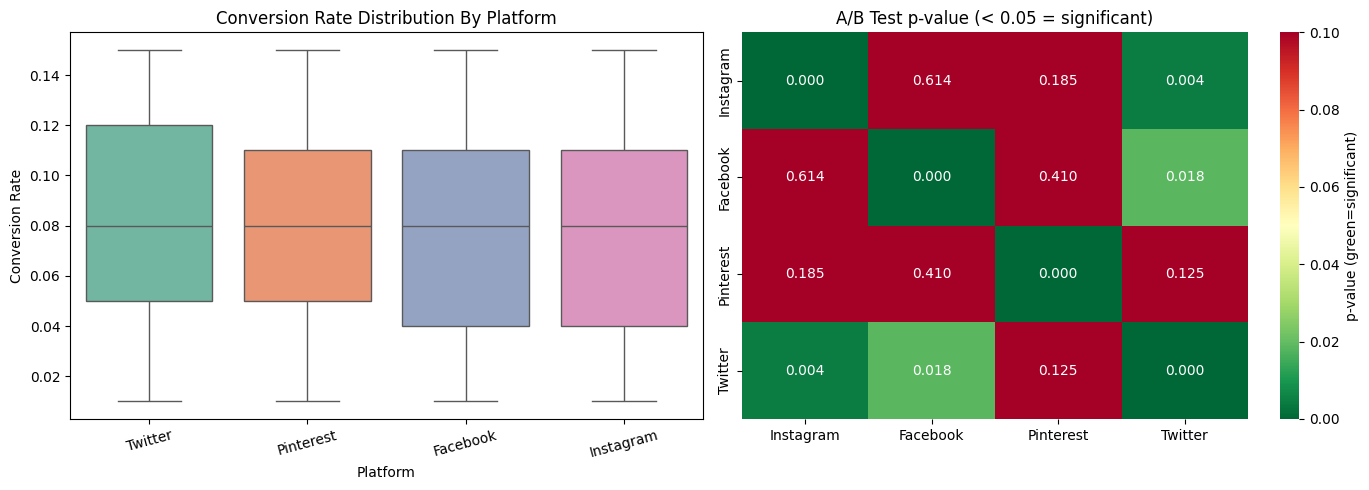

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes= plt.subplots(1,2,figsize=(14,5))

#Box plot- conversion rate distribution by platform
platform_order=df.groupby('channel_used')['conversion_rate'].mean().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    x='channel_used',
    y='conversion_rate',
    order=platform_order,
    ax=axes[0],
    palette='Set2'
)

axes[0].set_title('Conversion Rate Distribution By Platform')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Conversion Rate')
plt.sca(axes[0])
plt.xticks(rotation=15)

#Significance Heatmap
sig_matrix=pd.DataFrame(index=platforms,columns=platforms,dtype=float)
for _,row in ab_results.iterrows():
    p1,p2=row['comparison'].split(' vs ')
    sig_matrix.loc[p1,p2]=row['p_value']
    sig_matrix.loc[p2,p1]=row['p_value']

sig_matrix=sig_matrix.fillna(0).astype(float)
sns.heatmap(sig_matrix,annot=True,fmt='.3f',cmap='RdYlGn_r',ax=axes[1],vmin=0,vmax=0.1,cbar_kws={'label':'p-value (green=significant)'})
axes[1].set_title('A/B Test p-value (< 0.05 = significant)')

plt.tight_layout()
plt.savefig('../reports/figures/ab_test_results.png',dpi=150,bbox_inches='tight')
plt.show()




In [16]:
def cohens_d(group1,group2):
    """Calculate Cohen's d effect size"""
    n1,n2 =len(group1),len(group2)
    pooled_std=np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2)/(n1+n2-2))
    return (group1.mean()-group2.mean())/pooled_std


def interpret_d(d):
    d=abs(d)
    if d< 0.2: return 'Negligible'
    elif d< 0.5: return 'Small'
    elif d<0.8: return 'Medium'
    else: return 'Large'

for p1,p2 in combinations(platforms,2):
    g1=df[df['channel_used']==p1]['conversion_rate'].dropna()
    g2=df[df['channel_used']==p2]['conversion_rate'].dropna()
    d=cohens_d(g1,g2)
    print(f'{p1} vs {p2}: d={d:.3f} ({interpret_d(d)} effect)')

Instagram vs Facebook: d=-0.003 (Negligible effect)
Instagram vs Pinterest: d=-0.007 (Negligible effect)
Instagram vs Twitter: d=-0.015 (Negligible effect)
Facebook vs Pinterest: d=-0.004 (Negligible effect)
Facebook vs Twitter: d=-0.012 (Negligible effect)
Pinterest vs Twitter: d=-0.008 (Negligible effect)
